In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import resample
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

Veri setinin yüklenmesi

In [2]:
df = pd.read_csv('missense_mutations.csv')
df_filtered = df[df['ClinSigSimple'].isin([0, 1])].copy()

In [3]:
df_filtered

,#AlleleID,Type,Name,GeneID,GeneSymbol,HGNC_ID,ClinicalSignificance,ClinSigSimple,LastEvaluated,RS# (dbSNP),...,AlternateAlleleVCF,SomaticClinicalImpact,SomaticClinicalImpactLastEvaluated,ReviewStatusClinicalImpact,Oncogenicity,OncogenicityLastEvaluated,ReviewStatusOncogenicity,SCVsForAggregateGermlineClassification,SCVsForAggregateSomaticClinicalImpact,SCVsForAggregateOncogenicityClassification
0,24368,single nucleotide variant,NM_000059.4(BRCA2):c.1114A>C (p.Asn372His),675,BRCA2,HGNC:1101,Benign,0,"Jan 12, 2015",144848,...,C,-,-,-,-,-,-,SCV000245002,-,-
1,24368,single nucleotide variant,NM_000059.4(BRCA2):c.1114A>C (p.Asn372His),675,BRCA2,HGNC:1101,Benign,0,"Jan 12, 2015",144848,...,C,-,-,-,-,-,-,SCV000245002,-,-
2,24379,single nucleotide variant,NM_000059.4(BRCA2):c.8165C>G (p.Thr2722Arg),675,BRCA2,HGNC:1101,Pathogenic,1,"Aug 10, 2015",80359062,...,G,-,-,-,-,-,-,SCV000244480,-,-
3,24379,single nucleotide variant,NM_000059.4(BRCA2):c.8165C>G (p.Thr2722Arg),675,BRCA2,HGNC:1101,Pathogenic,1,"Aug 10, 2015",80359062,...,G,-,-,-,-,-,-,SCV000244480,-,-
4,24384,single nucleotide variant,NM_000059.4(BRCA2):c.7529T>C (p.Leu2510Pro),675,BRCA2,HGNC:1101,Pathogenic/Likely pathogenic,1,"Jul 09, 2024",80358979,...,C,-,-,-,-,-,-,SCV000567107|SCV000607817|SCV001478276|SCV0015...,-,-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11229,4185255,single nucleotide variant,NM_000059.4(BRCA2):c.8754G>C (p.Glu2918Asp),675,BRCA2,HGNC:1101,Likely pathogenic,1,"Jun 12, 2025",-1,...,C,-,-,-,-,-,-,SCV006298678,-,-
11230,4198803,single nucleotide variant,NM_000059.4(BRCA2):c.1307A>G (p.Lys436Arg),675,BRCA2,HGNC:1101,Uncertain significance,0,-,-1,...,G,-,-,-,-,-,-,SCV006333499,-,-
11231,4198803,single nucleotide variant,NM_000059.4(BRCA2):c.1307A>G (p.Lys436Arg),675,BRCA2,HGNC:1101,Uncertain significance,0,-,-1,...,G,-,-,-,-,-,-,SCV006333499,-,-
11232,4391609,single nucleotide variant,NM_007294.4(BRCA1):c.298G>C (p.Glu100Gln),672,BRCA1,HGNC:1100,Uncertain significance,0,"Jul 31, 2025",-1,...,G,-,-,-,-,-,-,SCV006554521,-,-


In [4]:
print(df_filtered['ClinSigSimple'].value_counts(normalize=True))

ClinSigSimple
0    0.907679
1    0.092321
Name: proportion, dtype: float64


Verilerin eşitlenmesi işlemi

In [5]:
df_majority = df_filtered[df_filtered.ClinSigSimple == 0]
df_minority = df_filtered[df_filtered.ClinSigSimple == 1]

df_majority_downsampled = resample(df_majority, 
                                 replace=False,    
                                 n_samples=len(df_minority),
                                 random_state=42)

df_balanced = pd.concat([df_majority_downsampled, df_minority])

In [6]:
print(len(df_majority_downsampled),len(df_minority))
df_balanced

832 832


,#AlleleID,Type,Name,GeneID,GeneSymbol,HGNC_ID,ClinicalSignificance,ClinSigSimple,LastEvaluated,RS# (dbSNP),...,AlternateAlleleVCF,SomaticClinicalImpact,SomaticClinicalImpactLastEvaluated,ReviewStatusClinicalImpact,Oncogenicity,OncogenicityLastEvaluated,ReviewStatusOncogenicity,SCVsForAggregateGermlineClassification,SCVsForAggregateSomaticClinicalImpact,SCVsForAggregateOncogenicityClassification
2764,69676,single nucleotide variant,NM_007294.4(BRCA1):c.3797G>C (p.Ser1266Thr),672,BRCA1,HGNC:1100,Benign,0,"Aug 10, 2015",80357160,...,G,-,-,-,-,-,-,SCV000244349,-,-
10201,854921,single nucleotide variant,NM_007294.4(BRCA1):c.50C>G (p.Ala17Gly),672,BRCA1,HGNC:1100,Uncertain significance,0,"Apr 11, 2023",1412871417,...,C,-,-,-,-,-,-,SCV004215165,-,-
4344,152547,single nucleotide variant,NM_000059.4(BRCA2):c.4873G>A (p.Glu1625Lys),675,BRCA2,HGNC:1101,Conflicting classifications of pathogenicity,0,"Jun 03, 2025",587782754,...,A,-,-,-,-,-,-,SCV000187351|SCV000278854|SCV000549736|SCV0009...,-,-
8415,853755,single nucleotide variant,NM_007294.4(BRCA1):c.5224A>C (p.Asn1742His),672,BRCA1,HGNC:1100,Uncertain significance,0,"May 09, 2023",1597810828,...,G,-,-,-,-,-,-,SCV001398234,-,-
4586,183637,single nucleotide variant,NM_000059.4(BRCA2):c.620C>T (p.Thr207Ile),675,BRCA2,HGNC:1101,Uncertain significance,0,"Aug 18, 2025",41293471,...,T,-,-,-,-,-,-,SCV000216436|SCV000279426|SCV000549716|SCV0008...,-,-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10877,2743216,single nucleotide variant,NM_000059.4(BRCA2):c.7870T>G (p.Tyr2624Asp),675,BRCA2,HGNC:1101,Pathogenic,1,"Sep 06, 2023",1161235543,...,G,-,-,-,-,-,-,SCV004032059,-,-
10988,2899000,single nucleotide variant,NM_000059.4(BRCA2):c.7985C>G (p.Thr2662Arg),675,BRCA2,HGNC:1101,Conflicting classifications of pathogenicity,1,"Aug 04, 2025",431825362,...,G,-,-,-,-,-,-,SCV004296246|SCV006586260,-,-
10989,2899000,single nucleotide variant,NM_000059.4(BRCA2):c.7985C>G (p.Thr2662Arg),675,BRCA2,HGNC:1101,Conflicting classifications of pathogenicity,1,"Aug 04, 2025",431825362,...,G,-,-,-,-,-,-,SCV004296246|SCV006586260,-,-
11228,4185255,single nucleotide variant,NM_000059.4(BRCA2):c.8754G>C (p.Glu2918Asp),675,BRCA2,HGNC:1101,Likely pathogenic,1,"Jun 12, 2025",-1,...,C,-,-,-,-,-,-,SCV006298678,-,-


Özelliklerin seçilmesi

In [7]:
features = ['GeneSymbol', 'Chromosome', 'Start', 'Stop', 'ReferenceAlleleVCF', 'AlternateAlleleVCF']
X = df_balanced[features].copy()
y = df_balanced['ClinSigSimple'].values

Kategorik verilerin düzenlenmesi

In [8]:
le = LabelEncoder()
for col in ['GeneSymbol', 'ReferenceAlleleVCF', 'AlternateAlleleVCF']:
    X[col] = le.fit_transform(X[col].astype(str))

Ölçeklendirme

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

RNN format

In [10]:
X_reshaped = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

Modelin bölünmesi eğitim / test

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y, test_size=0.2, random_state=42, stratify=y)

Modelin Oluşturulması 

In [12]:
model = Sequential([
    SimpleRNN(64, input_shape=(X_train.shape[1], X_train.shape[2]), activation='tanh'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid') # İkili sınıflandırma
])

C:\Users\emirh\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

Modelin eğitimi

In [14]:
model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=1)

Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5482 - loss: 0.6975
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6305 - loss: 0.6385
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6330 - loss: 0.6434
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6360 - loss: 0.6395 
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6534 - loss: 0.6209 
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6400 - loss: 0.6391
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6373 - loss: 0.6366
Epoch 8/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6426 - loss: 0.6331 
Epoch 9/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6387 - loss: 0.6385 
Epoch 10/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6353 - loss: 0.6439 
Epoch 11/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6430 - loss: 0.6289 
Epoch 12/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.636

Modelin test edilmesi

In [15]:
y_pred = (model.predict(X_test) > 0.5).astype(int)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.61      0.69      0.65       167
           1       0.64      0.56      0.60       166

    accuracy                           0.62       333
   macro avg       0.63      0.62      0.62       333
weighted avg       0.63      0.62      0.62       333



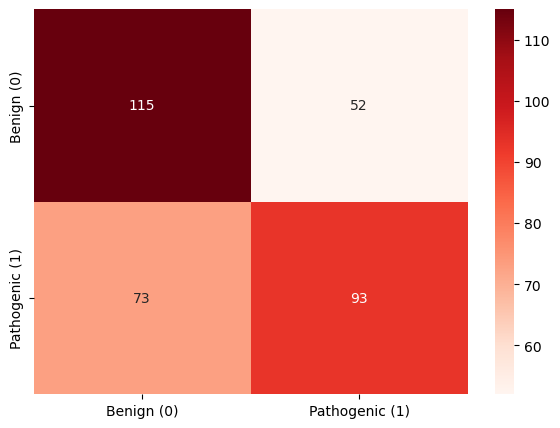

In [17]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Benign (0)', 'Pathogenic (1)'], 
            yticklabels=['Benign (0)', 'Pathogenic (1)'])
plt.show()

In [18]:
acc = accuracy_score(y_test, y_pred)
acc

0.6246246246246246

## Optuna Kullanımı

In [19]:
def objective(trial):
    # 1. Hiperparametre 
    n_layers = trial.suggest_int('n_layers', 1, 3) 
    lr = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
    
    model = Sequential()
    
    # 2. Dinamik RNN Mimarisi
    for i in range(n_layers):
        units = trial.suggest_int(f'rnn_units_l{i}', 16, 128, step=16)
        
        # RNN 
        is_last_rnn = (i == n_layers - 1)
        
        if i == 0:
            # Giriş katmanı 
            model.add(SimpleRNN(units, return_sequences=not is_last_rnn, 
                               input_shape=(X_train.shape[1], X_train.shape[2])))
        else:
            model.add(SimpleRNN(units, return_sequences=not is_last_rnn))
        
        model.add(Dropout(trial.suggest_float(f'dropout_l{i}', 0.1, 0.4)))
    
    # Çıkış Katmanı 
    model.add(Dense(1, activation='sigmoid'))

    # 3. Derleme
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    # 4. Eğitim 
    history = model.fit(
        X_train, y_train,
        epochs=15, 
        batch_size=batch_size,
        validation_split=0.2, 
        verbose=0
    )

    # 5. Skor  
    val_acc = history.history['val_accuracy'][-1]
    return val_acc

In [20]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

[I 2026-03-22 18:23:40,972] A new study created in memory with name: no-name-27f334ae-1f62-4aa0-9c85-022ebfb43de9
C:\Users\emirh\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
[I 2026-03-22 18:23:43,727] Trial 0 finished with value: 0.6516854166984558 and parameters: {'n_layers': 1, 'learning_rate': 0.0034084648524811156, 'batch_size': 64, 'rnn_units_l0': 48, 'dropout_l0': 0.1877831081953738}. Best is trial 0 with value: 0.6516854166984558.
[I 2026-03-22 18:23:47,463] Trial 1 finished with value: 0.6516854166984558 and parameters: {'n_layers': 1, 'learning_rate': 0.0009804119204597044, 'batch_size': 16, 'rnn_units_l0': 16, 'dropout_l0': 0.2431892347820775}. Best is trial 0 with value: 0.6516854166984558.
[I 2026-03-22 18:23:50,199] Trial 2 finished with value: 0.

In [21]:
print(f"En İyi RNN Skoru: {study.best_value:.4f}")
print("En İyi Parametreler:", study.best_params)

En İyi RNN Skoru: 0.6929
En İyi Parametreler: {'n_layers': 3, 'learning_rate': 0.0016447390118516435, 'batch_size': 64, 'rnn_units_l0': 128, 'dropout_l0': 0.1818000436172465, 'rnn_units_l1': 96, 'dropout_l1': 0.23945611111110693, 'rnn_units_l2': 64, 'dropout_l2': 0.1684432677699148}


## Threshold Değerinini Değiştirilmesi

Modele değerin 0.5 ten 0.45 e çekilerek başarımdaki farklılık değerlendirilecektir

In [22]:
y_pred2 = (model.predict(X_test) > 0.45).astype(int)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [23]:
print(classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

           0       0.65      0.63      0.64       167
           1       0.64      0.65      0.64       166

    accuracy                           0.64       333
   macro avg       0.64      0.64      0.64       333
weighted avg       0.64      0.64      0.64       333



In [24]:
cm2 = confusion_matrix(y_test, y_pred2)
cm2

array([[106,  61],
       [ 58, 108]], dtype=int64)

In [25]:
acc2 = accuracy_score(y_test, y_pred2)
acc2

0.6426426426426426